# Phase 0.5 - Environment Setup and Data Verification

Run all cells from top to bottom in Google Colab after mounting Drive. This notebook downloads the raw archives, extracts them, verifies HDF5 structure, saves sanity plots, and writes `results/00_environment_report.json`.


In [3]:
from google.colab import drive
from pathlib import Path

drive.mount('/content/drive')

REPO_ROOT = Path('/content/drive/MyDrive/seismic-first-break-picking')
if not REPO_ROOT.exists():
    raise FileNotFoundError(f'Repo path not found: {REPO_ROOT}')

print(f'Repo root found: {REPO_ROOT}')

def print_tree(root: Path, max_depth: int = 2, prefix: str = '') -> None:
    if max_depth < 0:
        return
    entries = sorted(root.iterdir(), key=lambda p: (p.is_file(), p.name.lower()))
    for entry in entries:
        print(f'{prefix}{entry.name}/' if entry.is_dir() else f'{prefix}{entry.name}')
        if entry.is_dir() and max_depth > 0:
            print_tree(entry, max_depth=max_depth - 1, prefix=prefix + '    ')

print('Repo tree preview:')
print_tree(REPO_ROOT, max_depth=2)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Repo root found: /content/drive/MyDrive/seismic-first-break-picking
Repo tree preview:
.git/
    hooks/
        applypatch-msg.sample
        commit-msg.sample
        fsmonitor-watchman.sample
        post-update.sample
        pre-applypatch.sample
        pre-commit.sample
        pre-merge-commit.sample
        pre-push.sample
        pre-rebase.sample
        pre-receive.sample
        prepare-commit-msg.sample
        push-to-checkout.sample
        update.sample
    info/
        exclude
    logs/
        refs/
        HEAD
    objects/
        03/
        0b/
        2b/
        32/
        34/
        38/
        3b/
        45/
        47/
        4d/
        50/
        51/
        57/
        5b/
        5c/
        5e/
        66/
        6c/
        72/
        83/
        94/
        9f/
        a1/
        a6/
        a9/
        ae/
        b

In [4]:
import os
import sys
from importlib import metadata
from pathlib import Path

# --------------------------------------------------------------------------
# 1. Package Configuration
# --------------------------------------------------------------------------
GENERAL_PACKAGES = {
    'h5py': '3.16.0',
    'numpy': '2.0.2',
    'pandas': '2.2.3',
    'matplotlib': '3.9.2',
    'seaborn': '0.13.2',
    'scipy': '1.14.1',
    'scikit-learn': '1.5.2',
    'tqdm': '4.67.1',
    'pyyaml': '6.0.2',
    'mlflow': '2.16.2',
    'optuna': '4.3.0',
    'lightgbm': '4.6.0',
    'xgboost': '2.1.4',
    'obspy': '1.4.1',
    'segmentation-models-pytorch': '0.5.0',
    'albumentations': '1.4.24',
}

TORCH_PACKAGES = {
    'torch': '2.5.1',
    'torchvision': '0.20.1',
}

ALL_PACKAGES = {**GENERAL_PACKAGES, **TORCH_PACKAGES}

def get_version(package_name):
    try:
        return metadata.version(package_name)
    except metadata.PackageNotFoundError:
        return None

def parse_version(v_str):
    if v_str is None: return (0, 0, 0)
    # Handle suffix like +cu124
    base_v = v_str.split('+')[0]
    try:
        return tuple(map(int, base_v.split('.')[:3]))
    except:
        return (0, 0, 0)

def check_environment():
    print(f"{'Package':<30} | {'Current':<12} | {'Required':<12} | {'Status'}")
    print("-" * 75)

    needs_install = []

    for pkg, req_v in ALL_PACKAGES.items():
        cur_v = get_version(pkg)

        # For torch/torchvision, we are stricter on major/minor but allow patch diffs
        # For general, we allow >= req_v
        is_ok = False
        if cur_v:
            cv = parse_version(cur_v)
            rv = parse_version(req_v)

            if pkg in ['torch', 'torchvision']:
                # Must match major.minor exactly, patch >= required
                is_ok = (cv[0] == rv[0] and cv[1] == rv[1] and cv[2] >= rv[2])
            else:
                # General: major >= required (but handle potential breakages if too new?)
                # For now: >= check is safer than exact equality in Colab
                is_ok = (cv >= rv)

        status = "OK" if is_ok else "MISMATCH" if cur_v else "MISSING"
        print(f"{pkg:<30} | {str(cur_v):<12} | {req_v:<12} | {status}")

        if not is_ok:
            needs_install.append(f"{pkg}=={req_v}")

    return needs_install

# --------------------------------------------------------------------------
# 2. Installation Logic
# --------------------------------------------------------------------------
needs_install = check_environment()

if not needs_install:
    print("\n[SUCCESS] Environment is already correctly configured. Proceeding to Cell 3.")
else:
    print(f"\n[ACTION] Installing/Updating {len(needs_install)} packages...")

    # We use !pip directly in Colab, but since this is script-based we'll use subprocess
    # but we switch to standard pip calls that show output
    import subprocess

    # Build the pip command
    cmd_general = [sys.executable, "-m", "pip", "install", "--upgrade"] + [p for p in needs_install if 'torch' not in p]
    if len(cmd_general) > 5:
        print("Running general installation...")
        subprocess.run(cmd_general, check=True)

    # Pytorch requires specific index
    torch_install = [p for p in needs_install if 'torch' in p]
    if torch_install:
        print("Running PyTorch installation...")
        subprocess.run([
            sys.executable, "-m", "pip", "install", "--upgrade",
            "--index-url", "https://download.pytorch.org/whl/cu124"
        ] + torch_install, check=True)

    print("\n" + "="*60)
    print("INSTALLATION COMPLETE")
    print("IMPORTANT: You MUST restart the runtime now (Runtime -> Restart session).")
    print("After restarting, click 'Run All' again.")
    print("="*60)

    # We use a cleaner exit to stop Run All without looking like a crash if possible
    try:
        from google.colab import runtime
        print("Attempting to stop execution safely...")
        # Note: we don't restart automatically because that can clear important state
        # and confuse the user if they were mashing buttons.
    except ImportError:
        pass

    # Manual stop to block Cell 3 from running with old numpy/torch binaries
    sys.exit("RESTART REQUIRED: Please restart the runtime to use updated packages.")


Package                        | Current      | Required     | Status
---------------------------------------------------------------------------
h5py                           | 3.16.0       | 3.16.0       | OK
numpy                          | 2.0.2        | 2.0.2        | OK
pandas                         | 2.2.3        | 2.2.3        | OK
matplotlib                     | 3.9.2        | 3.9.2        | OK
seaborn                        | 0.13.2       | 0.13.2       | OK
scipy                          | 1.14.1       | 1.14.1       | OK
scikit-learn                   | 1.5.2        | 1.5.2        | OK
tqdm                           | 4.67.1       | 4.67.1       | OK
pyyaml                         | 6.0.2        | 6.0.2        | OK
mlflow                         | 2.16.2       | 2.16.2       | OK
optuna                         | 4.3.0        | 4.3.0        | OK
lightgbm                       | 4.6.0        | 4.6.0        | OK
xgboost                        | 2.1.4        | 2.1.4        |

In [5]:
import torch

try:
    import torch_xla.core.xla_model as xm  # type: ignore
    TPU_AVAILABLE = True
except ImportError:
    TPU_AVAILABLE = False

if torch.cuda.is_available():
    device_type = 'CUDA'
    device_name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram_total_mb = props.total_memory // (1024 ** 2)
    free_bytes, total_bytes = torch.cuda.mem_get_info()
    vram_available_mb = free_bytes // (1024 ** 2)
    cuda_version = torch.version.cuda
    recommended_unet_batch = 8
    recommended_resnet_unet_batch = 4
elif TPU_AVAILABLE:
    device_type = 'TPU'
    device_name = str(xm.xla_device())
    vram_total_mb = None
    vram_available_mb = None
    cuda_version = 'N/A'
    recommended_unet_batch = 16
    recommended_resnet_unet_batch = 8
else:
    device_type = 'CPU'
    device_name = 'CPU'
    vram_total_mb = None
    vram_available_mb = None
    cuda_version = 'N/A'
    recommended_unet_batch = 1
    recommended_resnet_unet_batch = 1

DEVICE_REPORT = {
    'device_type': device_type,
    'device_name': device_name,
    'vram_total_mb': vram_total_mb,
    'vram_available_mb': vram_available_mb,
    'cuda_version': cuda_version,
    'pytorch_version': torch.__version__,
    'tpu_available': TPU_AVAILABLE,
    'recommended_batch_size_unet': recommended_unet_batch,
    'recommended_batch_size_resnet_unet': recommended_resnet_unet_batch,
}

print('=' * 60)
print('DEVICE REPORT')
print('=' * 60)
print(f"Device type     : {DEVICE_REPORT['device_type']}")
print(f"Device name     : {DEVICE_REPORT['device_name']}")
print(f"VRAM total      : {DEVICE_REPORT['vram_total_mb']} MB")
print(f"VRAM available  : {DEVICE_REPORT['vram_available_mb']} MB")
print(f"CUDA version    : {DEVICE_REPORT['cuda_version']}")
print(f"PyTorch version : {DEVICE_REPORT['pytorch_version']}")
print(f"TPU available   : {'Yes' if DEVICE_REPORT['tpu_available'] else 'No'}")
print(f"Recommended batch size (U-Net)      : {DEVICE_REPORT['recommended_batch_size_unet']}")
print(f"Recommended batch size (ResNet-UNet): {DEVICE_REPORT['recommended_batch_size_resnet_unet']}")
print('=' * 60)

if device_type == 'CPU':
    print('WARNING: CPU runtime detected. Training will be extremely slow. Switch to a GPU runtime before later phases.')


DEVICE REPORT
Device type     : CPU
Device name     : CPU
VRAM total      : None MB
VRAM available  : None MB
CUDA version    : N/A
PyTorch version : 2.5.1+cu124
TPU available   : No
Recommended batch size (U-Net)      : 1
Recommended batch size (ResNet-UNet): 1


In [6]:
import hashlib
import subprocess

RAW_DIR = REPO_ROOT / 'data' / 'raw'
RAW_DIR.mkdir(parents=True, exist_ok=True)

DATASET_SOURCES = {
    'brunswick': {
        'url': 'https://d3sakqnghgsk6x.cloudfront.net/Brunswick_3D/Brunswick_orig_1500ms_V2.hdf5.xz',
        'raw_filename': 'brunswick.hdf5.xz',
        'extracted_filename': 'brunswick.hdf5',
    },
    'halfmile': {
        'url': 'https://d3sakqnghgsk6x.cloudfront.net/Halfmile_3D/Halfmile3D_add_geom_sorted.hdf5.xz',
        'raw_filename': 'halfmile.hdf5.xz',
        'extracted_filename': 'halfmile.hdf5',
    },
    'lalor': {
        'url': 'https://d3sakqnghgsk6x.cloudfront.net/Lalor_3D/Lalor_raw_z_1500ms_norp_geom_v3.hdf5.xz',
        'raw_filename': 'lalor.hdf5.xz',
        'extracted_filename': 'lalor.hdf5',
    },
    'sudbury': {
        'url': 'https://d3sakqnghgsk6x.cloudfront.net/Sudbury_3D/preprocessed_Sudbury3D.hdf.xz',
        'raw_filename': 'sudbury.hdf.xz',
        'extracted_filename': 'sudbury.hdf5',
    },
}

def md5_for_file(path: Path, chunk_size: int = 1024 * 1024) -> str:
    digest = hashlib.md5()
    with path.open('rb') as handle:
        while True:
            chunk = handle.read(chunk_size)
            if not chunk:
                break
            digest.update(chunk)
    return digest.hexdigest()

DOWNLOAD_REPORT = {}

for asset, spec in DATASET_SOURCES.items():
    url = spec['url']
    target = RAW_DIR / spec['raw_filename']

    print()
    print(f'Downloading {asset} -> {target}')
    subprocess.run(['wget', '--continue', '--output-document', str(target), url], check=True)

    size_gb = round(target.stat().st_size / (1024 ** 3), 3)
    file_md5 = md5_for_file(target)
    DOWNLOAD_REPORT[asset] = {
        'path': str(target),
        'size_bytes': target.stat().st_size,
        'size_gb': size_gb,
        'md5': file_md5,
        'url': url,
    }
    print(f'{asset}: {size_gb} GB | md5={file_md5}')



brunswick: 8.444 GB | md5=a9960ed474c85f1628f85c4b6ff0ac8a

halfmile: 2.707 GB | md5=c31d79465ff41db2fd7be93e02570f08

lalor: 6.091 GB | md5=a16ab97a6335d92437dc36ae494eee5f

sudbury: 4.911 GB | md5=3e2c504ed4e10f9e34cbe053337d38c1


In [7]:
import h5py
import lzma
import shutil

EXTRACTED_DIR = REPO_ROOT / 'data' / 'extracted'
EXTRACTED_DIR.mkdir(parents=True, exist_ok=True)

EXTRACTION_REPORT = {}

def is_valid_hdf5(path: Path) -> bool:
    try:
        with h5py.File(path, 'r') as handle:
            _ = list(handle.keys())
        return True
    except Exception:
        return False

for asset, spec in DATASET_SOURCES.items():
    source = RAW_DIR / spec['raw_filename']
    target = EXTRACTED_DIR / spec['extracted_filename']

    if target.exists() and is_valid_hdf5(target):
        print(f'Skipping decompression - {target.name} already exists and opens as HDF5.')
    else:
        if target.exists():
            print(f'Removing partial or invalid file before retry: {target}')
            target.unlink()

        print(f'Decompressing {source.name} -> {target.name}')
        with lzma.open(source, 'rb') as src, target.open('wb') as dst:
            shutil.copyfileobj(src, dst)

        if not is_valid_hdf5(target):
            raise RuntimeError(f'Decompressed file is not a valid HDF5: {target}')

    size_gb = round(target.stat().st_size / (1024 ** 3), 3)
    EXTRACTION_REPORT[asset] = {
        'path': str(target),
        'size_bytes': target.stat().st_size,
        'size_gb': size_gb,
        'valid_hdf5': True,
    }
    print(f'{asset}: {size_gb} GB extracted and verified.')


Decompressing brunswick.hdf5.xz -> brunswick.hdf5
brunswick: 14.505 GB extracted and verified.
Decompressing halfmile.hdf5.xz -> halfmile.hdf5
halfmile: 3.489 GB extracted and verified.
Decompressing lalor.hdf5.xz -> lalor.hdf5
lalor: 14.597 GB extracted and verified.
Decompressing sudbury.hdf.xz -> sudbury.hdf5
sudbury: 7.525 GB extracted and verified.


In [8]:
import h5py
import numpy as np

EXPECTED_KEYS = [
    'data_array', 'SHOTID', 'SHOT_PEG', 'SOURCE_X', 'SOURCE_Y', 'SOURCE_HT',
    'REC_PEG', 'REC_X', 'REC_Y', 'REC_HT', 'SAMP_RATE', 'COORD_SCALE',
    'HT_SCALE', 'SAMP_NUM', 'SPARE1',
]

HDF5_REPORT = {}

def summarize_constant(dataset) -> dict:
    values = dataset[()]
    unique = np.unique(values)
    return {
        'is_constant': bool(unique.size == 1),
        'unique_count': int(unique.size),
        'value': unique[0].item() if unique.size == 1 else None,
    }

for asset, spec in DATASET_SOURCES.items():
    path = EXTRACTED_DIR / spec['extracted_filename']
    print('=' * 60)
    print(f'HDF5 STRUCTURAL VERIFICATION - {asset}')
    print('=' * 60)

    with h5py.File(path, 'r') as handle:
        root_groups = list(handle.keys())
        if 'TRACE_DATA' not in handle or 'DEFAULT' not in handle['TRACE_DATA']:
            raise KeyError(f'{asset}: TRACE_DATA/DEFAULT not found')

        group = handle['TRACE_DATA']['DEFAULT']
        present_keys = list(group.keys())
        missing_keys = [key for key in EXPECTED_KEYS if key not in group]
        undocumented_keys = [key for key in present_keys if key not in EXPECTED_KEYS]

        if missing_keys:
            raise KeyError(f'{asset}: missing keys {missing_keys}')

        key_summaries = {}
        for key in EXPECTED_KEYS:
            ds = group[key]
            key_summaries[key] = {'shape': list(ds.shape), 'dtype': str(ds.dtype)}
            print(f'{key:12s}: shape={ds.shape}, dtype={ds.dtype}')

        samp_rate = summarize_constant(group['SAMP_RATE'])
        coord_scale = summarize_constant(group['COORD_SCALE'])
        ht_scale = summarize_constant(group['HT_SCALE'])
        samp_num = summarize_constant(group['SAMP_NUM'])

        spare1 = group['SPARE1'][()]
        unique_values, counts = np.unique(spare1, return_counts=True)
        labeled_mask = np.logical_and(spare1 != 0, spare1 != -1)
        labeled_traces = int(labeled_mask.sum())
        total_traces = int(spare1.shape[0])

        HDF5_REPORT[asset] = {
            'file_path': str(path),
            'file_size_bytes': path.stat().st_size,
            'root_groups': root_groups,
            'target_group_found': True,
            'missing_keys': missing_keys,
            'undocumented_keys': undocumented_keys,
            'datasets': key_summaries,
            'samp_rate': samp_rate,
            'coord_scale': coord_scale,
            'ht_scale': ht_scale,
            'samp_num': samp_num,
            'labeled_traces': labeled_traces,
            'total_traces': total_traces,
            'labeled_fraction': labeled_traces / total_traces if total_traces else None,
            'spare1_value_counts': {str(v): int(c) for v, c in zip(unique_values.tolist(), counts.tolist())},
            'status': 'PASS',
        }

        print(f'Root groups: {root_groups}')
        print(f'Undocumented keys: {undocumented_keys if undocumented_keys else "none"}')
        print(f'SAMP_RATE constant: {samp_rate["is_constant"]} | value={samp_rate["value"]}')
        print(f'COORD_SCALE constant: {coord_scale["is_constant"]} | value={coord_scale["value"]}')
        print(f'HT_SCALE constant: {ht_scale["is_constant"]} | value={ht_scale["value"]}')
        print(f'SAMP_NUM constant: {samp_num["is_constant"]} | value={samp_num["value"]}')
        print(f'Labeled traces: {labeled_traces} / {total_traces} ({labeled_traces / total_traces:.2%})')
        print('STATUS: PASS')


HDF5 STRUCTURAL VERIFICATION - brunswick
data_array  : shape=(4496540, 751), dtype=float32
SHOTID      : shape=(4496540, 1), dtype=uint32
SHOT_PEG    : shape=(4496540, 1), dtype=uint32
SOURCE_X    : shape=(4496540, 1), dtype=int32
SOURCE_Y    : shape=(4496540, 1), dtype=int32
SOURCE_HT   : shape=(4496540, 1), dtype=int32
REC_PEG     : shape=(4496540, 1), dtype=uint32
REC_X       : shape=(4496540, 1), dtype=int32
REC_Y       : shape=(4496540, 1), dtype=int32
REC_HT      : shape=(4496540, 1), dtype=int32
SAMP_RATE   : shape=(4496540, 1), dtype=uint32
COORD_SCALE : shape=(4496540, 1), dtype=int32
HT_SCALE    : shape=(4496540, 1), dtype=int32
SAMP_NUM    : shape=(4496540, 1), dtype=uint32
SPARE1      : shape=(4496540, 1), dtype=int32
Root groups: ['TRACE_DATA']
Undocumented keys: ['ALIAS_FREQ', 'ALIAS_SLOPE', 'AZIMUTH', 'CDP', 'CDPTRACE', 'CDP_X', 'CDP_Y', 'CHANNEL', 'COORD_UNIT', 'CORR', 'CROSSLINE', 'DATA_START', 'DATA_STOP', 'DAY', 'DELAY', 'FIRST_BREAK_AMPLIT', 'FIRST_BREAK_TIME', 'FIR

/tmp/ipykernel_14100/2869687009.py:25: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  first_break_ms = float(spare1[idx])


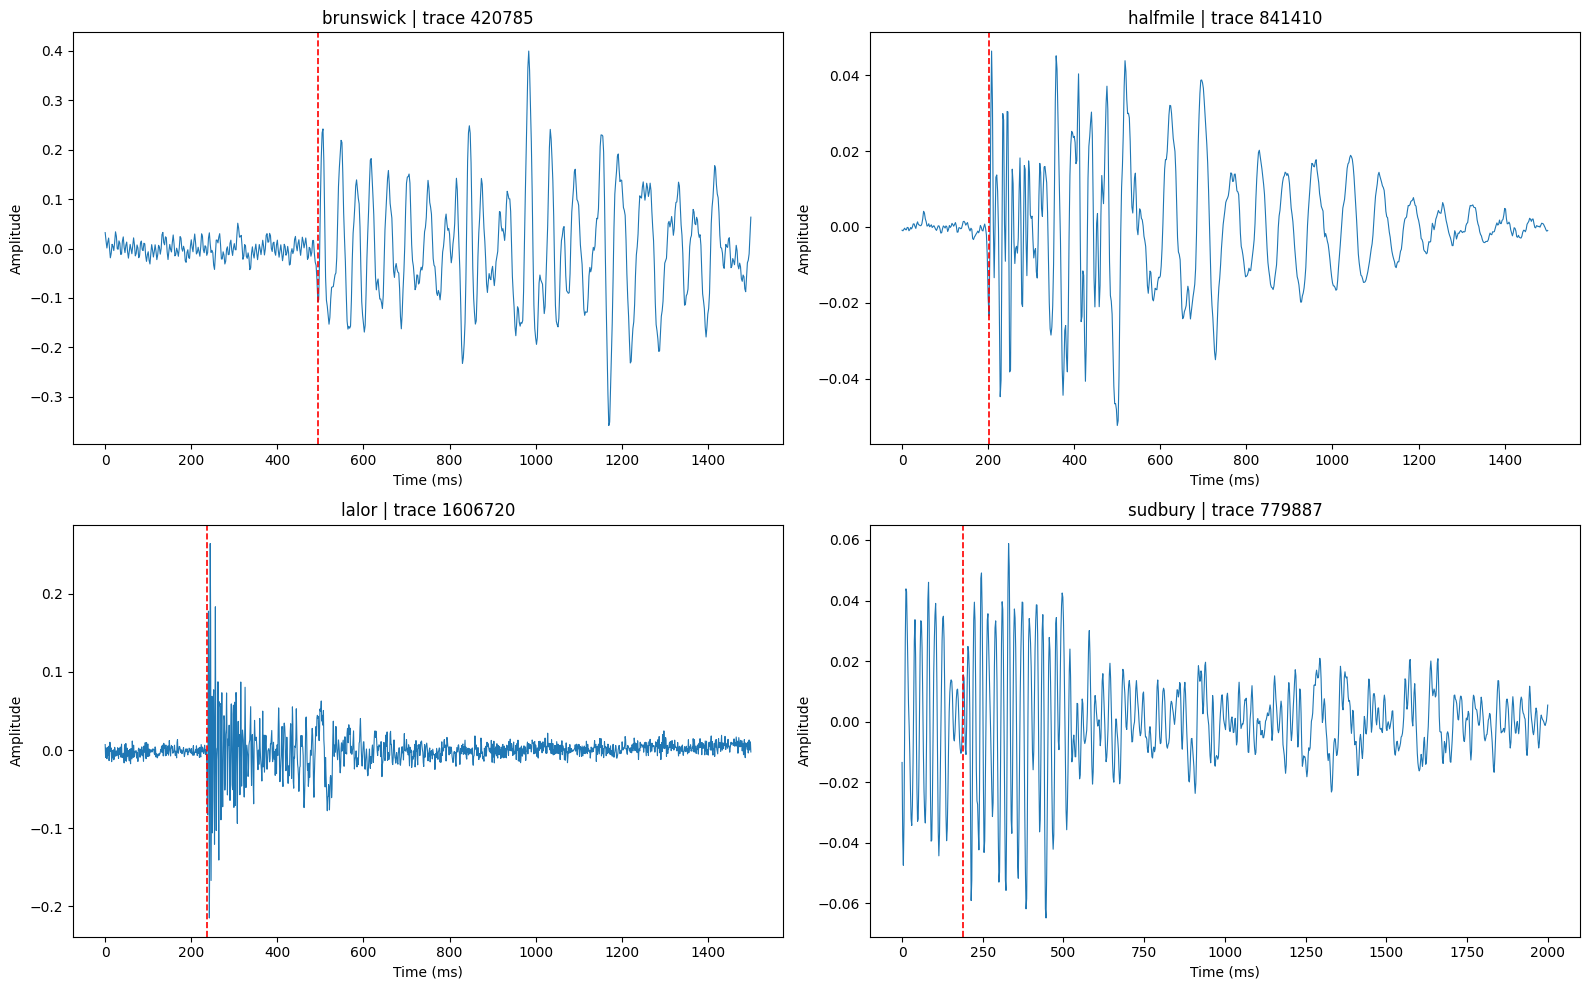

Saved sanity plot: /content/drive/MyDrive/seismic-first-break-picking/results/sanity_plots/00_first_traces.png


In [9]:
import matplotlib.pyplot as plt

SANITY_PLOT_PATH = REPO_ROOT / 'results' / 'sanity_plots' / '00_first_traces.png'
SANITY_PLOT_PATH.parent.mkdir(parents=True, exist_ok=True)

rng = np.random.default_rng(42)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

SANITY_REPORT = {}

for ax, (asset, spec) in zip(axes, DATASET_SOURCES.items()):
    path = EXTRACTED_DIR / spec['extracted_filename']
    with h5py.File(path, 'r') as handle:
        group = handle['TRACE_DATA']['DEFAULT']
        traces = group['data_array']
        spare1 = group['SPARE1'][()]

        labeled_indices = np.where(np.logical_and(spare1 != 0, spare1 != -1))[0]
        if labeled_indices.size == 0:
            raise RuntimeError(f'No labeled traces found for {asset}')

        idx = int(rng.choice(labeled_indices))
        trace = traces[idx]
        first_break_ms = float(spare1[idx])
        samp_rate_us = group['SAMP_RATE'][idx].item()
        time_axis_ms = np.arange(trace.shape[0]) * (samp_rate_us / 1000.0)

        ax.plot(time_axis_ms, trace, linewidth=0.8)
        ax.axvline(first_break_ms, color='red', linestyle='--', linewidth=1.2)
        ax.set_title(f'{asset} | trace {idx}')
        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude')

        SANITY_REPORT[asset] = {
            'trace_index': idx,
            'first_break_ms': first_break_ms,
            'sample_rate_us': samp_rate_us,
        }

plt.tight_layout()
plt.savefig(SANITY_PLOT_PATH, dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved sanity plot: {SANITY_PLOT_PATH}')


In [10]:
import json

REPORT_PATH = REPO_ROOT / 'results' / '00_environment_report.json'
REPORT_PATH.parent.mkdir(parents=True, exist_ok=True)

full_report = {
    'repo_root': str(REPO_ROOT),
    'device_report': DEVICE_REPORT,
    'download_report': DOWNLOAD_REPORT,
    'extraction_report': EXTRACTION_REPORT,
    'hdf5_report': HDF5_REPORT,
    'sanity_report': SANITY_REPORT,
    'sanity_plot_path': str(SANITY_PLOT_PATH),
}

with REPORT_PATH.open('w', encoding='utf-8') as handle:
    json.dump(full_report, handle, indent=2)

print('=' * 60)
print('PHASE 0.5 COMPLETE')
print('All four assets verified. Environment ready for Phase 1.')
print(f'Environment report saved to: {REPORT_PATH}')
print('=' * 60)


PHASE 0.5 COMPLETE
All four assets verified. Environment ready for Phase 1.
Environment report saved to: /content/drive/MyDrive/seismic-first-break-picking/results/00_environment_report.json
